# Police Crime Data — Gold Layer Preprocessing & Clustering (PySpark)

## 1. Install PySpark

In [21]:
!pip install pyspark --quiet

In [ ]:
import os
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler,
    RegexTokenizer, StopWordsRemover, CountVectorizer,
)
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture, LDA
from pyspark.ml.evaluation import ClusteringEvaluator

## 2. Open Spark Session

In [23]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

DATA_PATH = os.environ.get("DATA_PATH", "/content/drive/MyDrive/Colab Notebooks/NTI/police_cleaned.csv")
GOLD_PATH = os.environ.get("GOLD_PATH", "output/gold/police_clustering")
MODEL_OUTPUT_PATH = os.environ.get("MODEL_OUTPUT_PATH", "output/models/clustering")
CHECKPOINT_DIR = os.environ.get("SPARK_CHECKPOINT_DIR", "checkpoints")
SHUFFLE_PARTITIONS = os.environ.get("SPARK_SHUFFLE_PARTITIONS", "8")

spark = (SparkSession.builder
    .appName("police-clustering-gold")
    .config("spark.sql.shuffle.partitions", SHUFFLE_PARTITIONS)
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
spark.sparkContext.setCheckpointDir(CHECKPOINT_DIR)
spark

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Load Data and Sample Preview

In [24]:
df_raw = spark.read.csv(DATA_PATH, header=True, inferSchema=True)
print("Rows:", df_raw.count(), "| Columns:", len(df_raw.columns))
df_raw.show(5)

Rows: 100000 | Columns: 26
+----------+-------------+----------+---------------+-------------------+----------+-----------+---------+----------+-----------+---------+---------+---------+--------------+------------+------------------+----------------+--------------------+----------+-------------+--------------------+--------------------+---------------+------------------+--------------------+--------------+
|officer_id|     crime_id|crime_type|crime_date_only|         crime_time|crime_year|crime_month|crime_day|crime_hour|    country|     city| latitude|longitude|  officer_name|badge_number|victim_national_id|victim_full_name|victim_date_of_birth|victim_age|victim_gender|  victim_nationality|           narrative|  source_system|_data_quality_flag|        _ingested_at|   lookup_name|
+----------+-------------+----------+---------------+-------------------+----------+-----------+---------+----------+-----------+---------+---------+---------+--------------+------------+------------------+-

## 4. Cleaning

In [25]:
df = df_raw.dropDuplicates()

missing_tokens = ["", "null", "NULL", "na", "N/A", "n/a", "unknown", "Unknown"]
for c, t in df.dtypes:
    if t == "string":
        df = df.withColumn(c, F.when(F.trim(F.col(c)).isin(missing_tokens), None).otherwise(F.trim(F.col(c))))

DROP_COLUMNS = [
    "officer_id", "crime_id", "officer_name", "badge_number",
    "victim_national_id", "victim_full_name", "victim_date_of_birth",
    "source_system", "_data_quality_flag", "_ingested_at",
    "lookup_name", "crime_date_only", "crime_time",
]
df = df.drop(*[c for c in DROP_COLUMNS if c in df.columns])
df = df.withColumn("victim_nationality", F.coalesce(F.col("victim_nationality"), F.lit("Unknown")))
df = df.withColumn("narrative", F.coalesce(F.col("narrative"), F.lit("")))

## 5. Feature Engineering

In [26]:
df = df.withColumn("crime_date", F.to_date(F.concat_ws("-", "crime_year", "crime_month", "crime_day")))
df = df.withColumn("day_of_week", F.dayofweek("crime_date"))
df = df.withColumn("is_weekend", F.when(F.col("day_of_week").isin(1, 7), 1).otherwise(0))
df = df.drop("crime_date").cache()

print("Rows after cleaning:", df.count())
df.show(5)

Rows after cleaning: 100000
+----------------+----------+-----------+---------+----------+-------+---------+---------+---------+----------+-------------+------------------+--------------------+-----------+----------+
|      crime_type|crime_year|crime_month|crime_day|crime_hour|country|     city| latitude|longitude|victim_age|victim_gender|victim_nationality|           narrative|day_of_week|is_weekend|
+----------------+----------+-----------+---------+----------+-------+---------+---------+---------+----------+-------------+------------------+--------------------+-----------+----------+
|           Theft|      2026|          6|        4|        23| France|    Paris|48.826779| 2.314254|        69|         Male|              Oman|Environmental def...|          5|         0|
|      Cybercrime|      2024|          5|       12|        23|Belgium| Brussels|  50.8533| 4.337601|        92|       Female|          Zimbabwe|Never candidate o...|          1|         1|
|           Fraud|      202

## 6. Geographic Feature Preparation

In [27]:
geo_df = df.select("latitude", "longitude").withColumn("point_id", F.monotonically_increasing_id())

geo_assembler = VectorAssembler(inputCols=["latitude", "longitude"], outputCol="raw_features")
geo_scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=False, withStd=True)

geo_assembled = geo_assembler.transform(geo_df)
scaled_df = geo_scaler.fit(geo_assembled).transform(geo_assembled).cache()
scaled_df.count()

100000

## 7. Model 1 — KMeans (Baseline)

In [28]:
K = int(os.environ.get("K", "16"))
evaluator = ClusteringEvaluator(featuresCol="features")

kmeans = KMeans(featuresCol="features", predictionCol="kmeans_cluster", k=K, seed=42)
kmeans_model = kmeans.fit(scaled_df)
kmeans_preds = kmeans_model.transform(scaled_df)

kmeans_silhouette = evaluator.setPredictionCol("kmeans_cluster").evaluate(kmeans_preds)
print("KMeans Silhouette:", kmeans_silhouette)
kmeans_preds.groupBy("kmeans_cluster").count().orderBy("kmeans_cluster").show()

KMeans Silhouette: 0.9984574295829703
+--------------+-----+
|kmeans_cluster|count|
+--------------+-----+
|             0|12536|
|             1| 6186|
|             2| 6243|
|             3| 6308|
|             4| 6304|
|             5| 4224|
|             6| 4141|
|             7| 4084|
|             8| 6189|
|             9| 4203|
|            10| 4261|
|            11| 6291|
|            12| 6359|
|            13|12303|
|            14| 4172|
|            15| 6196|
+--------------+-----+



## 8. Model 2 — Bisecting KMeans (Hierarchical)

In [29]:
bkm = BisectingKMeans(featuresCol="features", predictionCol="bkm_cluster", k=K, seed=42)
bkm_model = bkm.fit(scaled_df)
bkm_preds = bkm_model.transform(scaled_df)

bkm_silhouette = evaluator.setPredictionCol("bkm_cluster").evaluate(bkm_preds)
print("BisectingKMeans Silhouette:", bkm_silhouette)
bkm_preds.groupBy("bkm_cluster").count().orderBy("bkm_cluster").show()

BisectingKMeans Silhouette: 0.7983439747823922
+-----------+-----+
|bkm_cluster|count|
+-----------+-----+
|          0| 6304|
|          1| 6359|
|          2| 8485|
|          3|12375|
|          4| 6269|
|          5| 6267|
|          6| 2100|
|          7| 2072|
|          8|12303|
|          9| 4141|
|         10|12504|
|         11| 4203|
|         12| 4084|
|         13| 6291|
|         14| 3143|
|         15| 3100|
+-----------+-----+



## 9. Model 3 — Gaussian Mixture Model (GMM)

In [30]:
GMM_K = int(os.environ.get("GMM_K", "16"))
GMM_SEEDS = [0, 1, 42, 99]

best_gmm_model, best_gmm_preds, best_gmm_silhouette = None, None, -1.0
for seed in GMM_SEEDS:
    candidate = GaussianMixture(featuresCol="features", predictionCol="gmm_cluster", k=GMM_K, seed=seed, maxIter=100, tol=1e-4)
    candidate_model = candidate.fit(scaled_df)
    candidate_preds = candidate_model.transform(scaled_df)
    candidate_silhouette = evaluator.setPredictionCol("gmm_cluster").evaluate(candidate_preds)
    if candidate_silhouette > best_gmm_silhouette:
        best_gmm_model, best_gmm_preds, best_gmm_silhouette = candidate_model, candidate_preds, candidate_silhouette

gmm_model, gmm_preds, gmm_silhouette = best_gmm_model, best_gmm_preds, best_gmm_silhouette
print("GMM Silhouette (best of", len(GMM_SEEDS), "seeds, k=", GMM_K, "):", gmm_silhouette)
gmm_preds.groupBy("gmm_cluster").count().orderBy("gmm_cluster").show()

GMM Silhouette (best of 4 seeds, k= 16 ): 0.6640499650693683
+-----------+-----+
|gmm_cluster|count|
+-----------+-----+
|          0|12534|
|          1| 3104|
|          2|  746|
|          3|12504|
|          4|12663|
|          5| 1341|
|          6| 1276|
|          7| 5440|
|          8|12657|
|          9|12303|
|         10| 4084|
|         11|  468|
|         12|  195|
|         13| 4141|
|         14|12536|
|         15| 4008|
+-----------+-----+



## 10. NLP on Narrative (LDA Preparation)

DBSCAN was replaced with LDA (Latent Dirichlet Allocation) as the pure PySpark DBSCAN is very time-consuming for the entire dataset. LDA is a native Spark ML model that only requires SQL/DataFrame, without any external libraries or JARs, providing a practical use for the narrative feature instead of dropping it.

In [31]:
df_text = df.withColumn("narrative_clean", F.lower(F.col("narrative")))
df_text = df_text.withColumn("narrative_clean", F.regexp_replace("narrative_clean", r"[^a-z\s]", " "))

tokenizer = RegexTokenizer(inputCol="narrative_clean", outputCol="tokens", pattern=r"\W+", minTokenLength=2)
remover = StopWordsRemover(inputCol="tokens", outputCol="tokens_clean")
df_text = remover.transform(tokenizer.transform(df_text))

TEXT_VOCAB_SIZE = int(os.environ.get("TEXT_VOCAB_SIZE", "3000"))
cv = CountVectorizer(inputCol="tokens_clean", outputCol="text_tf", vocabSize=TEXT_VOCAB_SIZE, minDF=2.0)
cv_model = cv.fit(df_text)
df_text = cv_model.transform(df_text)

## 11. Model 4 — LDA (Topic Modeling on Narrative)

In [32]:
TOPICS = int(os.environ.get("TOPICS", "8"))

lda = LDA(k=TOPICS, maxIter=20, seed=42, featuresCol="text_tf", topicDistributionCol="topic_distribution")
lda_model = lda.fit(df_text)
lda_preds = lda_model.transform(df_text)

print("LDA logLikelihood:", lda_model.logLikelihood(df_text))
print("LDA logPerplexity:", lda_model.logPerplexity(df_text))

vocab = cv_model.vocabulary
for topic_id, indices, weights in lda_model.describeTopics(5).rdd.map(
    lambda r: (r["topic"], r["termIndices"], r["termWeights"])
).collect():
    print(f"Topic {topic_id}: {[vocab[i] for i in indices]}")

LDA logLikelihood: -6779092.681252146
LDA logPerplexity: 7.084179976102998
Topic 0: ['officer', 'public', 'factor', 'upon', 'participant']
Topic 1: ['reveal', 'part', 'plan', 'address', 'three']
Topic 2: ['role', 'final', 'become', 'spend', 'keep']
Topic 3: ['fund', 'rock', 'generation', 'suffer', 'relate']
Topic 4: ['organization', 'win', 'center', 'always', 'north']
Topic 5: ['protect', 'particular', 'almost', 'economy', 'carry']
Topic 6: ['team', 'subject', 'watch', 'beat', 'political']
Topic 7: ['current', 'show', 'mission', 'western', 'successful']


## 12. Model Comparison

In [33]:
comparison = spark.createDataFrame([
    ("KMeans", kmeans_silhouette, K),
    ("BisectingKMeans", bkm_silhouette, K),
    ("GMM", gmm_silhouette, K),
    ("LDA", lda_model.logPerplexity(df_text), TOPICS),
], ["model", "score", "k"])
comparison.show()

+---------------+------------------+---+
|          model|             score|  k|
+---------------+------------------+---+
|         KMeans|0.9984574295829703| 16|
|BisectingKMeans|0.7983439747823922| 16|
|            GMM|0.6640499650693683| 16|
|            LDA| 7.084179976102998|  8|
+---------------+------------------+---+



## 13. Visualization

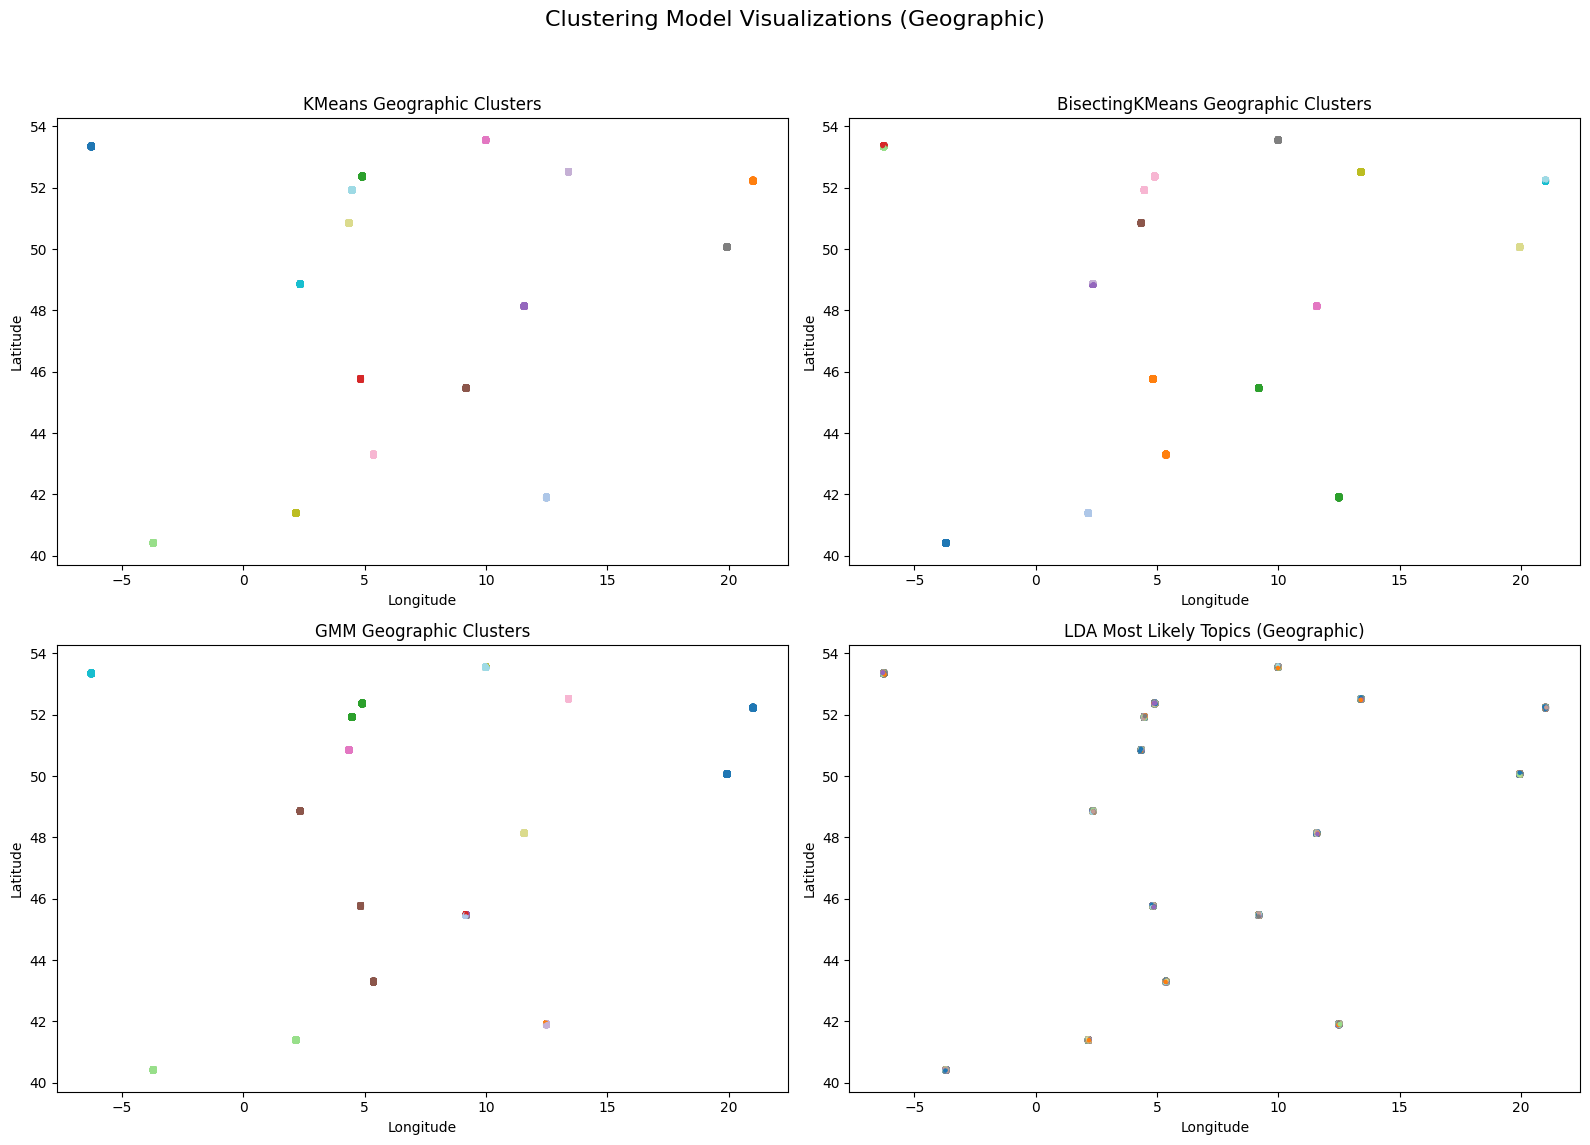

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType
import pyspark.sql.functions as F # Re-adding this import

@udf(IntegerType())
def get_most_likely_topic(topic_dist_vector):
    if topic_dist_vector is None:
        return None
    return int(np.argmax(topic_dist_vector.toArray()))
kmeans_pd = kmeans_preds.select("latitude", "longitude", "kmeans_cluster").toPandas()
bkm_pd = bkm_preds.select("latitude", "longitude", "bkm_cluster").toPandas()
gmm_pd = gmm_preds.select("latitude", "longitude", "gmm_cluster").toPandas()

lda_preds_with_topic = lda_preds.withColumn("lda_topic", get_most_likely_topic(F.col("topic_distribution")))
lda_pd = lda_preds_with_topic.select("latitude", "longitude", "lda_topic").toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Clustering Model Visualizations (Geographic)", fontsize=16)

axes[0, 0].scatter(kmeans_pd["longitude"], kmeans_pd["latitude"], c=kmeans_pd["kmeans_cluster"], cmap="tab20", s=5)
axes[0, 0].set_title("KMeans Geographic Clusters")
axes[0, 0].set_xlabel("Longitude")
axes[0, 0].set_ylabel("Latitude")

axes[0, 1].scatter(bkm_pd["longitude"], bkm_pd["latitude"], c=bkm_pd["bkm_cluster"], cmap="tab20", s=5)
axes[0, 1].set_title("BisectingKMeans Geographic Clusters")
axes[0, 1].set_xlabel("Longitude")
axes[0, 1].set_ylabel("Latitude")

axes[1, 0].scatter(gmm_pd["longitude"], gmm_pd["latitude"], c=gmm_pd["gmm_cluster"], cmap="tab20", s=5)
axes[1, 0].set_title("GMM Geographic Clusters")
axes[1, 0].set_xlabel("Longitude")
axes[1, 0].set_ylabel("Latitude")

axes[1, 1].scatter(lda_pd["longitude"], lda_pd["latitude"], c=lda_pd["lda_topic"], cmap="tab20", s=5)
axes[1, 1].set_title("LDA Most Likely Topics (Geographic)")
axes[1, 1].set_xlabel("Longitude")
axes[1, 1].set_ylabel("Latitude")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 14. Save Models

In [35]:
kmeans_model.write().overwrite().save(os.path.join(MODEL_OUTPUT_PATH, "kmeans"))
bkm_model.write().overwrite().save(os.path.join(MODEL_OUTPUT_PATH, "bisecting_kmeans"))
gmm_model.write().overwrite().save(os.path.join(MODEL_OUTPUT_PATH, "gmm"))
lda_model.write().overwrite().save(os.path.join(MODEL_OUTPUT_PATH, "lda"))
cv_model.write().overwrite().save(os.path.join(MODEL_OUTPUT_PATH, "count_vectorizer"))

print("All models saved to:", MODEL_OUTPUT_PATH)

All models saved to: output/models/clustering


## 15. Save Gold Layer

In [36]:
gold_df = (
    df.join(kmeans_preds.select("latitude", "longitude", "kmeans_cluster"), ["latitude", "longitude"], "left")
      .join(bkm_preds.select("latitude", "longitude", "bkm_cluster"), ["latitude", "longitude"], "left")
      .join(gmm_preds.select("latitude", "longitude", "gmm_cluster"), ["latitude", "longitude"], "left")
      .dropDuplicates()
)

gold_df.write.mode("overwrite").parquet(GOLD_PATH)
print("Gold layer saved to:", GOLD_PATH, "| rows:", gold_df.count())

Gold layer saved to: output/gold/police_clustering | rows: 100000


## 16. Close Session

In [37]:
# spark.stop()

---
## Notes for Data Engineering / Integration

- **The data produced from preprocessing (steps 4-6) should be placed in the Gold Layer**, not the Silver layer received from you. The order is: Bronze (raw Kafka) → Silver (your cleaned data) → This notebook takes Silver and produces Gold (preprocessing + features + clustering results).
- The Gold Layer is saved in the path specified by `GOLD_PATH` (parquet format), and includes: all preprocessing columns + a cluster column for each model (kmeans_cluster, bkm_cluster, gmm_cluster).
- The trained models (KMeans, BisectingKMeans, GMM, LDA, CountVectorizer) are saved in `MODEL_OUTPUT_PATH` in native Spark ML format. They can be reloaded using `Model.load(path)` without retraining.
- All paths are environment variables; no code modification is needed, just adjust the values in `docker-compose`: `DATA_PATH`, `GOLD_PATH`, `MODEL_OUTPUT_PATH`, `SPARK_CHECKPOINT_DIR`, `SPARK_SHUFFLE_PARTITIONS`.
- DBSCAN was replaced with LDA (on the narrative column) because pure PySpark DBSCAN is very slow for the full dataset. If DBSCAN is desired, it can be added as a fifth, additional model, not a replacement.